# **4. Data Splitting**

### **4.1 Load Clean Data**

In [ ]:
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

file_path = "/content/drive/My Drive/Major Project/clean_dataset.csv"
df_final = pd.read_csv(file_path)

Mounted at /content/drive


In [ ]:
df_final

,clean_text,language,Category,VADER_Compound
0,dear vaccine advocate do take the covid19 mrna...,en,Negative,-0.6757
1,world at least 6 dead and 16 injured in russia...,es,Negative,-0.7906
2,animal shelter dogs and cats we need your help...,en,Positive,0.8225
3,welcome to our shelter located in ukraine kyiv...,en,Positive,0.6908
4,tension because russia is still standing at th...,es,Negative,-0.5423
...,...,...,...,...
45181,not about me because i would never dare fortun...,uk,Neutral,0.0000
45182,everything as usual just another russian gover...,en,Positive,0.4215
45183,roulette ep7 ukraine president zelensky the he...,es,Neutral,0.0000
45184,roulette ep7 ukraine president zelensky the he...,es,Neutral,0.0000


### **4.2 Prepare Labels**

In [ ]:
sent_label = {'Positive': 2, 'Neutral': 1, 'Negative': 0}
df_final['MLlabel'] = df_final['Category'].map(sent_label)

### **4.3 Train-Test Split**

In [ ]:
from sklearn.model_selection import train_test_split

X = df_final['clean_text']
y = df_final['MLlabel']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train Set: {len(X_train)} samples")
print(f"Test Set:  {len(X_test)} samples")
print(f"\nTrain Label Distribution:\n{y_train.value_counts()}")
print(f"\nTest Label Distribution:\n{y_test.value_counts()}")

Train Set: 36148 samples
Test Set:  9038 samples

Train Label Distribution:
MLlabel
0    14000
2    12067
1    10081
Name: count, dtype: int64

Test Label Distribution:
MLlabel
0    3500
2    3017
1    2521
Name: count, dtype: int64


# **5. Feature Extraction**

### **5.1 TF-IDF Vectorization**

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer(max_features=10000, ngram_range=(1, 2), min_df=2, max_df=0.95)

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print(f"TF-IDF Train Shape: {X_train_tfidf.shape}")
print(f"TF-IDF Test Shape:  {X_test_tfidf.shape}")

TF-IDF Train Shape: (36148, 10000)
TF-IDF Test Shape:  (9038, 10000)


### **5.2 Bag-of-Words Vectorization**

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

bow_vectorizer = CountVectorizer(max_features=10000, ngram_range=(1, 2), min_df=2, max_df=0.95)

X_train_bow = bow_vectorizer.fit_transform(X_train)
X_test_bow = bow_vectorizer.transform(X_test)

print(f"BoW Train Shape: {X_train_bow.shape}")
print(f"BoW Test Shape:  {X_test_bow.shape}")

BoW Train Shape: (36148, 10000)
BoW Test Shape:  (9038, 10000)


# **6. Machine Learning Models Training**

### **6.1 Linear Regression**

======= Linear Regression =======

Accuracy: 0.6780261119716752

Classification Report:
              precision    recall  f1-score   support

    Negative       0.89      0.62      0.73      3500
     Neutral       0.48      0.88      0.62      2521
    Positive       0.87      0.58      0.70      3017

    accuracy                           0.68      9038
   macro avg       0.75      0.69      0.68      9038
weighted avg       0.77      0.68      0.69      9038



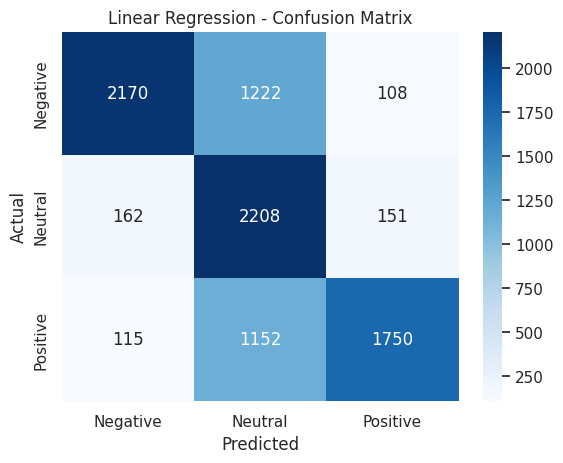

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

classes = ['Negative', 'Neutral', 'Positive']
linreg_model = LinearRegression()
linreg_model.fit(X_train_tfidf, y_train)

y_pred_linreg_cont = linreg_model.predict(X_test_tfidf)
y_pred_linreg = np.clip(np.rint(y_pred_linreg_cont), 0, 2).astype(int)

print('======= Linear Regression =======')
print(f"\nAccuracy:", accuracy_score(y_test, y_pred_linreg))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_linreg, target_names=classes))

cm_linreg = confusion_matrix(y_test, y_pred_linreg, labels=[0, 1, 2])
sns.heatmap(cm_linreg, annot=True, fmt="d", cmap="Blues", xticklabels=classes, yticklabels=classes)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Linear Regression - Confusion Matrix")
plt.show()

### **6.2 Logistic Regression**

======= Logistic Regression =======

Accuracy: 0.8187652135428192

Classification Report:
              precision    recall  f1-score   support

    Negative       0.82      0.84      0.83      3500
     Neutral       0.80      0.83      0.81      2521
    Positive       0.83      0.79      0.81      3017

    accuracy                           0.82      9038
   macro avg       0.82      0.82      0.82      9038
weighted avg       0.82      0.82      0.82      9038



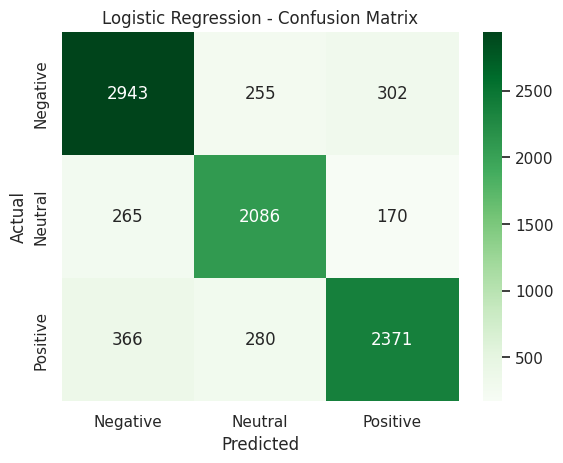

In [ ]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(X_train_tfidf, y_train)
y_pred_log = log_model.predict(X_test_tfidf)

print('======= Logistic Regression =======')
print(f"\nAccuracy:", accuracy_score(y_test, y_pred_log))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_log, target_names=classes))

cm_log = confusion_matrix(y_test, y_pred_log, labels=[0, 1, 2])
sns.heatmap(cm_log, annot=True, fmt='d', cmap='Greens', xticklabels=classes, yticklabels=classes)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Logistic Regression - Confusion Matrix')
plt.show()

### **6.3 Naive Bayes (Multinomial)**

======= Naive Bayes =======

Accuracy: 0.7001549015268865

Classification Report:
              precision    recall  f1-score   support

    Negative       0.65      0.85      0.74      3500
     Neutral       0.76      0.55      0.64      2521
    Positive       0.75      0.65      0.69      3017

    accuracy                           0.70      9038
   macro avg       0.72      0.68      0.69      9038
weighted avg       0.71      0.70      0.70      9038



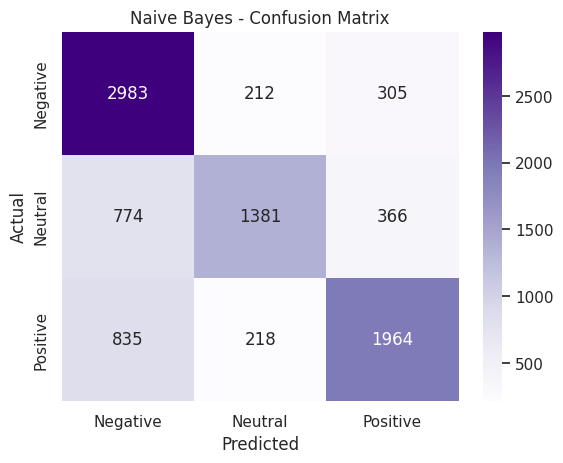

In [ ]:
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)
y_pred_nb = nb_model.predict(X_test_tfidf)

print('======= Naive Bayes =======')
print(f"\nAccuracy:", accuracy_score(y_test, y_pred_nb))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_nb, target_names=classes))

cm_nb = confusion_matrix(y_test, y_pred_nb, labels=[0, 1, 2])
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Purples', xticklabels=classes, yticklabels=classes)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Naive Bayes - Confusion Matrix')
plt.show()

### **6.4 SVM (Linear Support Vector Machine)**

======= Support Vector Machine =======

Accuracy: 0.8431068820535517

Classification Report:
              precision    recall  f1-score   support

    Negative       0.86      0.86      0.86      3500
     Neutral       0.81      0.87      0.84      2521
    Positive       0.85      0.81      0.83      3017

    accuracy                           0.84      9038
   macro avg       0.84      0.84      0.84      9038
weighted avg       0.84      0.84      0.84      9038



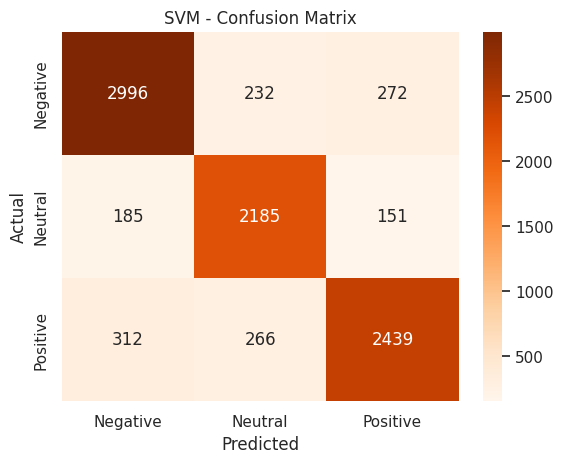

In [ ]:
from sklearn.svm import LinearSVC

svc_model = LinearSVC(max_iter=1000, random_state=42)
svc_model.fit(X_train_tfidf, y_train)
y_pred_svc = svc_model.predict(X_test_tfidf)

print('======= Support Vector Machine =======')
print(f"\nAccuracy:", accuracy_score(y_test, y_pred_svc))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_svc, target_names=classes))

cm_svc = confusion_matrix(y_test, y_pred_svc, labels=[0, 1, 2])
sns.heatmap(cm_svc, annot=True, fmt='d', cmap='Oranges', xticklabels=classes, yticklabels=classes)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('SVM - Confusion Matrix')
plt.show()

### **6.5 Decision Tree**

======= Decision Tree =======

Accuracy: 0.5538836025669396

Classification Report:
              precision    recall  f1-score   support

    Negative       0.77      0.42      0.55      3500
     Neutral       0.56      0.57      0.57      2521
    Positive       0.46      0.70      0.55      3017

    accuracy                           0.55      9038
   macro avg       0.60      0.56      0.55      9038
weighted avg       0.61      0.55      0.55      9038



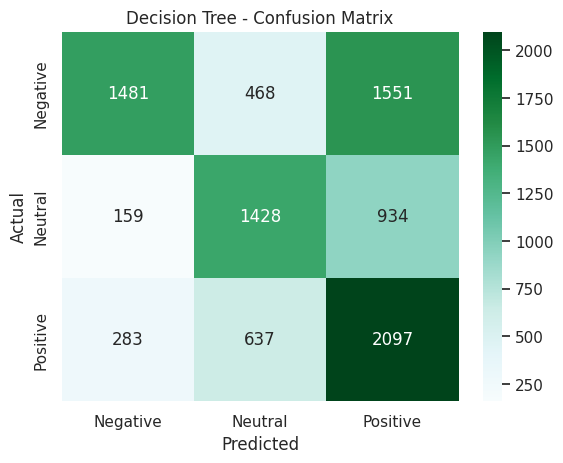

In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(max_depth=10, random_state=42)
dt_model.fit(X_train_tfidf, y_train)
y_pred_dt = dt_model.predict(X_test_tfidf)

print('======= Decision Tree =======')
print(f"\nAccuracy:", accuracy_score(y_test, y_pred_dt))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt, target_names=classes))

cm_dt = confusion_matrix(y_test, y_pred_dt, labels=[0, 1, 2])
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='BuGn', xticklabels=classes, yticklabels=classes)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Decision Tree - Confusion Matrix')
plt.show()

### **6.6 Random Forest**

======= Random Forest =======

Accuracy: 0.5427085638415579

Classification Report:
              precision    recall  f1-score   support

    Negative       0.46      0.97      0.63      3500
     Neutral       0.82      0.34      0.48      2521
    Positive       0.96      0.21      0.35      3017

    accuracy                           0.54      9038
   macro avg       0.75      0.51      0.49      9038
weighted avg       0.73      0.54      0.49      9038



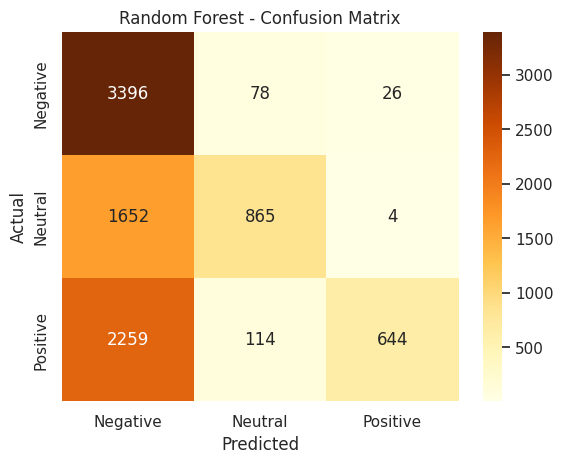

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf_model.fit(X_train_tfidf, y_train)
y_pred_rf = rf_model.predict(X_test_tfidf)

print('======= Random Forest =======')
print(f"\nAccuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf, target_names=classes))

cm_rf = confusion_matrix(y_test, y_pred_rf, labels=[0, 1, 2])
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='YlOrBr', xticklabels=classes, yticklabels=classes)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Random Forest - Confusion Matrix')
plt.show()

### **6.7 KNN (K-Nearest Neighbor)**

======= K-Nearest Neighbor =======

Accuracy: 0.41004647045806597

Classification Report:
              precision    recall  f1-score   support

    Negative       0.90      0.18      0.29      3500
     Neutral       0.32      0.98      0.48      2521
    Positive       0.93      0.21      0.34      3017

    accuracy                           0.41      9038
   macro avg       0.72      0.45      0.37      9038
weighted avg       0.75      0.41      0.36      9038



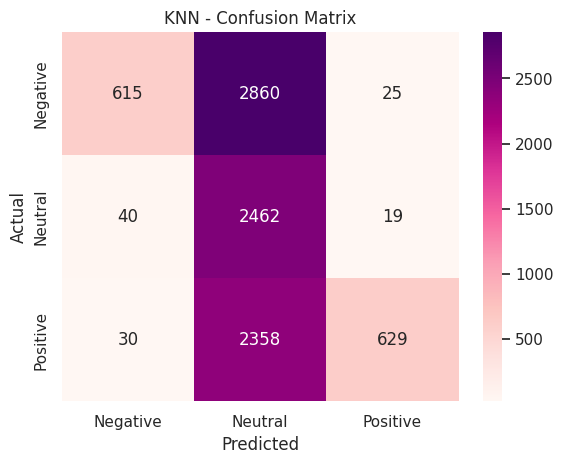

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
knn_model.fit(X_train_tfidf, y_train)
y_pred_knn = knn_model.predict(X_test_tfidf)

print('======= K-Nearest Neighbor =======')
print(f"\nAccuracy:", accuracy_score(y_test, y_pred_knn))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_knn, target_names=classes))

cm_knn = confusion_matrix(y_test, y_pred_knn, labels=[0, 1, 2])
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='RdPu', xticklabels=classes, yticklabels=classes)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('KNN - Confusion Matrix')
plt.show()

### **6.8 XGBoost (Extreme Gradient Boosting)**

======= XGBoost =======

Accuracy: 0.78900199159106

Classification Report:
              precision    recall  f1-score   support

    Negative       0.83      0.77      0.80      3500
     Neutral       0.72      0.87      0.79      2521
    Positive       0.82      0.74      0.78      3017

    accuracy                           0.79      9038
   macro avg       0.79      0.79      0.79      9038
weighted avg       0.79      0.79      0.79      9038



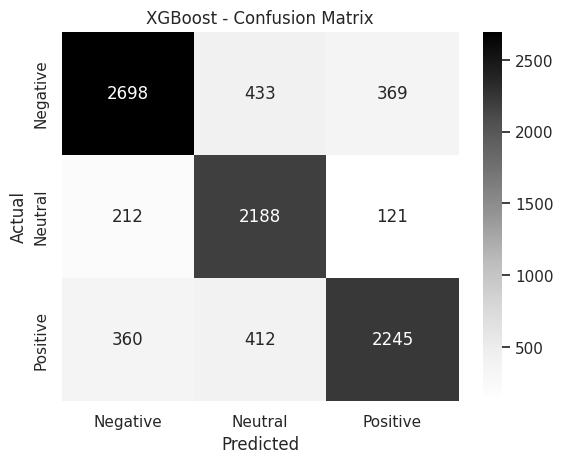

In [ ]:
import xgboost as xgb
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    objective='multi:softmax',
    num_class=3,
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1)

xgb_model.fit(X_train_tfidf, y_train)
y_pred_xgb = xgb_model.predict(X_test_tfidf)

print('======= XGBoost =======')
print(f"\nAccuracy:", accuracy_score(y_test, y_pred_xgb))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb, target_names=classes))

cm_xgb = confusion_matrix(y_test, y_pred_xgb, labels=[0, 1, 2])
sns.heatmap(cm_xgb, annot=True, fmt="d", cmap="Greys", xticklabels=classes, yticklabels=classes)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("XGBoost - Confusion Matrix")
plt.show()

# **7. Results and Analysis (Machine Learning)**

### **7.1 Machine Learning Models Accuracy Comparison**

In [ ]:
from sklearn.metrics import accuracy_score

model_names = ["Support Vector Machine", "Logistic Regression", "XGBoost", "Naive Bayes", "Linear Regression", "Decision Tree", "Random Forest", "K-Nearest Neighbor"]

accuracies = [
    accuracy_score(y_test, y_pred_svc),
    accuracy_score(y_test, y_pred_log),
    accuracy_score(y_test, y_pred_xgb),
    accuracy_score(y_test, y_pred_nb),
    accuracy_score(y_test, y_pred_linreg),
    accuracy_score(y_test, y_pred_dt),
    accuracy_score(y_test, y_pred_rf),
    accuracy_score(y_test, y_pred_knn)]

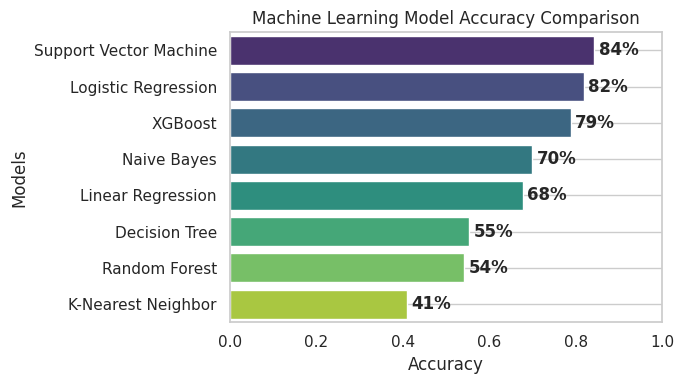

In [ ]:
accuracy_labels = [f"{acc:.0%}" for acc in accuracies]

sns.set(style="whitegrid")
plt.figure(figsize=(7, 4))
ax = sns.barplot(y=model_names, x=accuracies, orient="h", palette="viridis")
plt.xlim(0, 1)
plt.xlabel('Accuracy')
plt.ylabel('Models')
plt.title('Machine Learning Model Accuracy Comparison')

for i, (value, label) in enumerate(zip(accuracies, accuracy_labels)):
    ax.text(value + 0.01, i, label, va='center', fontweight='bold')

plt.tight_layout()
plt.grid()
plt.show()

### **7.2 ROC-AUC Curve of ML Models**

In [ ]:
from sklearn.preprocessing import label_binarize

classes = [0, 1, 2]
Y_test_bin = label_binarize(y_test, classes=classes)
n_classes = Y_test_bin.shape[1]

y_score_svc = svc_model.decision_function(X_test_tfidf)
y_score_log = log_model.predict_proba(X_test_tfidf)
y_score_xgb = xgb_model.predict_proba(X_test_tfidf)
y_score_nb = nb_model.predict_proba(X_test_tfidf)
y_score_dt = dt_model.predict_proba(X_test_tfidf)
y_score_rf = rf_model.predict_proba(X_test_tfidf)
y_score_knn = knn_model.predict_proba(X_test_tfidf)

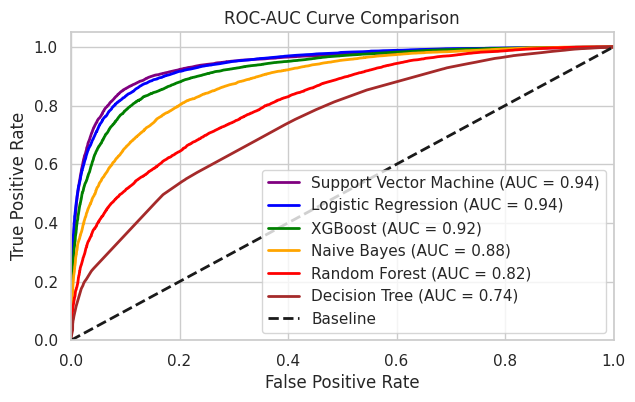

In [ ]:
from sklearn.metrics import roc_curve, auc

model_scores = [
    ('Support Vector Machine', y_score_svc),
    ('Logistic Regression', y_score_log),
    ('XGBoost', y_score_xgb),
    ('Naive Bayes', y_score_nb),
    ('Random Forest', y_score_rf),
    ('Decision Tree', y_score_dt),
    ('KNN', y_score_knn)]

plt.figure(figsize=(7, 4))
colors = ['purple', 'blue', 'green', 'orange', 'red', 'brown']

for (label, score), color in zip(model_scores, colors):
    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(Y_test_bin[:, i], score[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])
    all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
    mean_tpr = np.zeros_like(all_fpr)
    for i in range(n_classes):
        mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
    mean_tpr /= n_classes
    macro_auc = auc(all_fpr, mean_tpr)
    plt.plot(all_fpr, mean_tpr, color=color, label=f'{label} (AUC = {macro_auc:.2f})', lw=2)

plt.plot([0,1], [0,1], 'k--', lw=2, label='Baseline')
plt.xlim([0.0, 1.0]); plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-AUC Curve Comparison')
plt.legend(loc='lower right')
plt.show()

# **8. Deep Learning Model Algorithms**

### **8.1 MLP (Multi-Layer Perceptron)**

In [ ]:
import tensorflow as tf
import scipy.sparse as sp

from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import *
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import MultiHeadAttention, LayerNormalization

max_words = 15000
max_len = 64

tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding='post')

In [ ]:
mlp_model = Sequential([
    Embedding(max_words, 128, input_length=max_len),
    GlobalAveragePooling1D(),
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.4),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(3, activation='softmax')])

mlp_model.compile(optimizer=Adam(0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

history_mlp = mlp_model.fit(
    X_train_pad, y_train,
    validation_data=(X_test_pad, y_test),
    epochs=20,
    batch_size=128,
    callbacks=[EarlyStopping(patience=4, restore_best_weights=True)],
    verbose=1)

mlp_loss, mlp_acc = mlp_model.evaluate(X_test_pad, y_test, verbose=0)
print(f"\nMLP Accuracy: {mlp_acc}")

Epoch 1/20
283/283 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.6125 - loss: 0.8233 - val_accuracy: 0.5539 - val_loss: 0.9062
Epoch 2/20
283/283 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8901 - loss: 0.3210 - val_accuracy: 0.6852 - val_loss: 0.6553
Epoch 3/20
283/283 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9240 - loss: 0.2195 - val_accuracy: 0.8457 - val_loss: 0.4611
Epoch 4/20
283/283 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9305 - loss: 0.1900 - val_accuracy: 0.8293 - val_loss: 0.6488
Epoch 5/20
283/283 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9502 - loss: 0.1362 - val_accuracy: 0.8202 - val_loss: 0.8389
Epoch 6/20
283/283 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9534 - loss: 0.1233 - val_accuracy: 0.8390 - val_loss: 0.6919
Epoch 7/20
283/283 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9592 - loss: 0.1068 - val_accuracy: 0.6894 - val_loss: 3.0033

MLP Accuracy: 0.8456516861915588


### **8.2 CNN (Convolutional Neural Network)**

In [ ]:
cnn_model = Sequential([
    Embedding(max_words, 128, input_length=max_len),
    Conv1D(256, 5, activation='relu'),
    Conv1D(128, 5, activation='relu'),
    GlobalMaxPooling1D(),
    BatchNormalization(),
    Dropout(0.4),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(3, activation='softmax')])

cnn_model.compile(optimizer=Adam(0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

history_cnn = cnn_model.fit(
    X_train_pad, y_train,
    validation_data=(X_test_pad, y_test),
    epochs=20,
    batch_size=128,
    callbacks=[EarlyStopping(patience=4, restore_best_weights=True)],
    verbose=1)

cnn_loss, cnn_acc = cnn_model.evaluate(X_test_pad, y_test, verbose=0)
print(f"\nCNN Accuracy: {cnn_acc}")

Epoch 1/20
283/283 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - accuracy: 0.5718 - loss: 0.8863 - val_accuracy: 0.7466 - val_loss: 0.7437
Epoch 2/20
283/283 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8843 - loss: 0.3411 - val_accuracy: 0.8817 - val_loss: 0.3519
Epoch 3/20
283/283 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9359 - loss: 0.1987 - val_accuracy: 0.8925 - val_loss: 0.3604
Epoch 4/20
283/283 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9581 - loss: 0.1324 - val_accuracy: 0.8956 - val_loss: 0.3930
Epoch 5/20
283/283 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9729 - loss: 0.0888 - val_accuracy: 0.8910 - val_loss: 0.4113
Epoch 6/20
283/283 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9780 - loss: 0.0682 - val_accuracy: 0.8927 - val_loss: 0.4392

CNN Accuracy: 0.8817216157913208


### **8.3 RNN (Recurrent Neural Network)**

In [ ]:
rnn_model = Sequential([
    Embedding(max_words, 128, input_length=max_len),
    SimpleRNN(64, return_sequences=True),
    Dropout(0.3),
    SimpleRNN(32),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(3, activation='softmax')])

rnn_model.compile(optimizer=Adam(0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

history_rnn = rnn_model.fit(
    X_train_pad, y_train,
    validation_data=(X_test_pad, y_test),
    epochs=20,
    batch_size=128,
    callbacks=[EarlyStopping(patience=4, restore_best_weights=True)],
    verbose=1)

rnn_loss, rnn_acc = rnn_model.evaluate(X_test_pad, y_test, verbose=0)
print(f"\nRNN Accuracy: {rnn_acc}")

Epoch 1/20
283/283 ━━━━━━━━━━━━━━━━━━━━ 14s 28ms/step - accuracy: 0.3944 - loss: 1.0844 - val_accuracy: 0.5839 - val_loss: 0.8547
Epoch 2/20
283/283 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.6255 - loss: 0.7947 - val_accuracy: 0.6451 - val_loss: 0.7685
Epoch 3/20
283/283 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.7648 - loss: 0.5809 - val_accuracy: 0.7060 - val_loss: 0.7443
Epoch 4/20
283/283 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.8555 - loss: 0.4073 - val_accuracy: 0.7229 - val_loss: 0.8032
Epoch 5/20
283/283 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.8971 - loss: 0.3067 - val_accuracy: 0.7197 - val_loss: 0.8187
Epoch 6/20
283/283 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.9277 - loss: 0.2244 - val_accuracy: 0.7257 - val_loss: 0.9055
Epoch 7/20
283/283 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.9424 - loss: 0.1884 - val_accuracy: 0.7390 - val_loss: 1.0585

RNN Accuracy: 0.7060190439224243


### **8.4 LSTM (Long Short-Term Memory)**

In [ ]:
lstm_model = Sequential([
    Embedding(max_words, 128, input_length=max_len),
    LSTM(64, return_sequences=True),
    Dropout(0.3),
    LSTM(32),
    Dropout(0.3),
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(3, activation='softmax')])

lstm_model.compile(optimizer=Adam(0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

history_lstm = lstm_model.fit(
    X_train_pad, y_train,
    validation_data=(X_test_pad, y_test),
    epochs=20,
    batch_size=128,
    callbacks=[EarlyStopping(patience=4, restore_best_weights=True)],
    verbose=1)

lstm_loss, lstm_acc = lstm_model.evaluate(X_test_pad, y_test, verbose=0)
print(f"\nLSTM Accuracy: {lstm_acc}")

Epoch 1/20
283/283 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - accuracy: 0.4135 - loss: 1.0451 - val_accuracy: 0.5817 - val_loss: 0.8411
Epoch 2/20
283/283 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.7812 - loss: 0.5555 - val_accuracy: 0.8526 - val_loss: 0.4376
Epoch 3/20
283/283 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.9077 - loss: 0.3009 - val_accuracy: 0.8397 - val_loss: 0.4581
Epoch 4/20
283/283 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.9402 - loss: 0.2111 - val_accuracy: 0.8858 - val_loss: 0.3623
Epoch 5/20
283/283 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9518 - loss: 0.1670 - val_accuracy: 0.8950 - val_loss: 0.3808
Epoch 6/20
283/283 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.9624 - loss: 0.1307 - val_accuracy: 0.8927 - val_loss: 0.4309
Epoch 7/20
283/283 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.9672 - loss: 0.1180 - val_accuracy: 0.8846 - val_loss: 0.4194
Epoch 8/20
283/283 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.9713 - loss: 0.0973 - val_accu

### **8.5 Transformer**

In [ ]:
def transformer_block(inputs, head_size=64, num_heads=4, ff_dim=128):
    attn = MultiHeadAttention(num_heads=num_heads, key_dim=head_size)(inputs, inputs)
    attn = Dropout(0.2)(attn)
    out1 = LayerNormalization()(inputs + attn)
    ffn = Dense(ff_dim, activation="relu")(out1)
    ffn = Dense(inputs.shape[-1])(ffn)
    ffn = Dropout(0.2)(ffn)
    return LayerNormalization()(out1 + ffn)

inputs = Input(shape=(max_len,))
x = Embedding(max_words, 128)(inputs)
x = LSTM(64, return_sequences=True)(x)
x = transformer_block(x)
x = GlobalAveragePooling1D()(x)
x = Dropout(0.3)(x)
x = Dense(64, activation='relu')(x)
outputs = Dense(3, activation='softmax')(x)

transformer_model = Model(inputs, outputs)
transformer_model.compile(optimizer=Adam(0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

history_transformer = transformer_model.fit(
    X_train_pad, y_train,
    validation_data=(X_test_pad, y_test),
    epochs=20,
    batch_size=128,
    callbacks=[EarlyStopping(patience=4, restore_best_weights=True)],
    verbose=1)

transformer_loss, transformer_acc = transformer_model.evaluate(X_test_pad, y_test, verbose=0)
print(f"\nTransformer Accuracy: {transformer_acc}")

Epoch 1/20
283/283 ━━━━━━━━━━━━━━━━━━━━ 10s 18ms/step - accuracy: 0.5127 - loss: 0.9757 - val_accuracy: 0.8455 - val_loss: 0.4128
Epoch 2/20
283/283 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.9023 - loss: 0.2944 - val_accuracy: 0.8905 - val_loss: 0.3275
Epoch 3/20
283/283 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - accuracy: 0.9458 - loss: 0.1737 - val_accuracy: 0.8977 - val_loss: 0.3228
Epoch 4/20
283/283 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.9604 - loss: 0.1262 - val_accuracy: 0.8922 - val_loss: 0.3438
Epoch 5/20
283/283 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - accuracy: 0.9680 - loss: 0.0988 - val_accuracy: 0.8915 - val_loss: 0.4332
Epoch 6/20
283/283 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.9740 - loss: 0.0754 - val_accuracy: 0.8899 - val_loss: 0.4385
Epoch 7/20
283/283 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.9822 - loss: 0.0512 - val_accuracy: 0.8931 - val_loss: 0.4521

Transformer Accuracy: 0.8976543545722961


### **8.6 Hybrid (CNN + LSTM)**

In [ ]:
hybrid_model = Sequential([
    Embedding(max_words, 128, input_length=max_len),
    Conv1D(256, 5, activation='relu', padding='same'),
    BatchNormalization(),
    Conv1D(128, 3, activation='relu', padding='same'),
    MaxPooling1D(2),
    Dropout(0.3),

    Bidirectional(LSTM(64, return_sequences=True)),
    Dropout(0.3),
    Bidirectional(LSTM(32)),
    Dropout(0.3),

    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.4),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(3, activation='softmax')])

hybrid_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'])

history_hybrid = hybrid_model.fit(
    X_train_pad, y_train,
    validation_data=(X_test_pad, y_test),
    epochs=20,
    batch_size=128,
    callbacks=[EarlyStopping(monitor='val_accuracy', patience=4, restore_best_weights=True)],
    verbose=1)

hybrid_loss, hybrid_acc = hybrid_model.evaluate(X_test_pad, y_test, verbose=0)
print(f"\nHybrid Accuracy: {hybrid_acc}")

Epoch 1/20
283/283 ━━━━━━━━━━━━━━━━━━━━ 19s 29ms/step - accuracy: 0.4243 - loss: 1.1732 - val_accuracy: 0.6743 - val_loss: 0.8486
Epoch 2/20
283/283 ━━━━━━━━━━━━━━━━━━━━ 7s 25ms/step - accuracy: 0.8288 - loss: 0.4847 - val_accuracy: 0.8805 - val_loss: 0.3441
Epoch 3/20
283/283 ━━━━━━━━━━━━━━━━━━━━ 6s 22ms/step - accuracy: 0.9285 - loss: 0.2407 - val_accuracy: 0.9003 - val_loss: 0.3150
Epoch 4/20
283/283 ━━━━━━━━━━━━━━━━━━━━ 7s 26ms/step - accuracy: 0.9510 - loss: 0.1643 - val_accuracy: 0.8978 - val_loss: 0.3621
Epoch 5/20
283/283 ━━━━━━━━━━━━━━━━━━━━ 6s 22ms/step - accuracy: 0.9653 - loss: 0.1183 - val_accuracy: 0.9020 - val_loss: 0.3909
Epoch 6/20
283/283 ━━━━━━━━━━━━━━━━━━━━ 10s 23ms/step - accuracy: 0.9742 - loss: 0.0916 - val_accuracy: 0.9043 - val_loss: 0.4253
Epoch 7/20
283/283 ━━━━━━━━━━━━━━━━━━━━ 7s 25ms/step - accuracy: 0.9785 - loss: 0.0724 - val_accuracy: 0.9071 - val_loss: 0.4296
Epoch 8/20
283/283 ━━━━━━━━━━━━━━━━━━━━ 6s 22ms/step - accuracy: 0.9796 - loss: 0.0671 - val_ac

### **8.7 GAN (Generative Adversarial Network)**

In [ ]:
class SimpleGAN:
    def __init__(self, latent_dim=100, input_dim=None):
        self.latent_dim = latent_dim
        self.input_dim = input_dim
        self.generator = self.build_generator()
        self.discriminator = self.build_discriminator()

    def build_generator(self):
        model = Sequential([
            Dense(256, activation='relu', input_dim=self.latent_dim),
            Dense(512, activation='relu'),
            Dense(self.input_dim, activation='sigmoid')])
        return model

    def build_discriminator(self):
        model = Sequential([
            Dense(512, activation='relu', input_dim=self.input_dim),
            Dropout(0.3),
            Dense(256, activation='relu'),
            Dense(1, activation='sigmoid')])
        model.compile(loss='binary_crossentropy', optimizer=Adam(0.0002, 0.5))
        return model

input_dim = X_train_tfidf.shape[1]
gan = SimpleGAN(latent_dim=100, input_dim=input_dim)

num_fake_samples = 3000
noise = np.random.normal(0, 1, (num_fake_samples, gan.latent_dim))
fake_samples = gan.generator.predict(noise, verbose=0)

X_aug = sp.vstack([X_train_tfidf, fake_samples])
y_aug = np.concatenate([y_train, np.random.choice(y_train, size=num_fake_samples)])

gan_classifier = RandomForestClassifier(n_estimators=200, random_state=42)
gan_classifier.fit(X_aug, y_aug)

y_pred_gan = gan_classifier.predict(X_test_tfidf)
gan_acc = accuracy_score(y_test, y_pred_gan)

print(f"\nGAN Accuracy: {gan_acc}")


GAN Accuracy: 0.7475105111750387


### **8.8 BERT (Bidirectional Encoder Representations from Transformers)**

In [ ]:
import os
os.environ["WANDB_DISABLED"] = "true"
os.environ["TOKENIZERS_PARALLELISM"] = "false"

import logging
logging.getLogger("huggingface_hub.utils._http").setLevel(logging.ERROR)
logging.getLogger("huggingface_hub.file_download").setLevel(logging.ERROR)

import torch
from datasets import Dataset
from transformers import (AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments, DataCollatorWithPadding)

model_name = "distilbert-base-multilingual-cased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

train_df = pd.DataFrame({"text": X_train.values, "label": y_train.values})
test_df  = pd.DataFrame({"text": X_test.values,  "label": y_test.values})

train_data = Dataset.from_pandas(train_df)
test_data  = Dataset.from_pandas(test_df)

def tokenize(batch):
    return tokenizer(batch["text"], truncation=True)

train_enc = train_data.map(tokenize, batched=True)
test_enc  = test_data.map(tokenize, batched=True)

train_enc.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])
test_enc.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])

bert_model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=3)

training_args = TrainingArguments(
    output_dir="./bert_results",
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    learning_rate=2e-5,
    weight_decay=0.01,
    logging_steps=100,
    eval_strategy="epoch",
    save_strategy="no",
    report_to="none")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {"accuracy": (preds == labels).mean()}

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

trainer = Trainer(
    model=bert_model,
    args=training_args,
    train_dataset=train_enc,
    eval_dataset=test_enc,
    data_collator=data_collator,
    compute_metrics=compute_metrics)

trainer.train()
results = trainer.evaluate()
bert_acc = results['eval_accuracy']
print(f"\nBERT Accuracy: {results['eval_accuracy']}")

config.json:   0%|          | 0.00/466 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/996k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.96M [00:00<?, ?B/s]

Map:   0%|          | 0/36148 [00:00<?, ? examples/s]

...

model.safetensors:   0%|          | 0.00/542M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-multilingual-cased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy
1,0.338265,0.319434,0.889135
2,0.218572,0.284000,0.913255
3,0.200103,0.290529,0.919119



BERT Accuracy: 0.9191192741757026


# **9. Results and Analysis (Deep Learning)**

### **9.1 Deep Learning Models Accuracy Comparison**

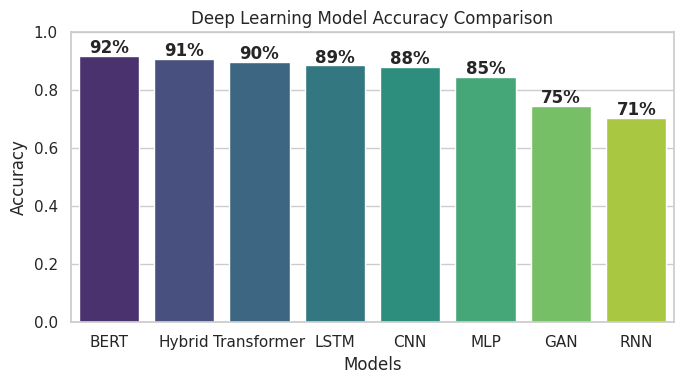

In [ ]:
model_names_dl = ["RNN", "GAN", "MLP", "Transformer", "CNN", "LSTM","Hybrid", "BERT"]
accuracies_dl = [rnn_acc, gan_acc, mlp_acc, transformer_acc, cnn_acc, lstm_acc, hybrid_acc, bert_acc]

accuracy_labels_dl = [f"{acc:.0%}" for acc in accuracies_dl]
sorted_idx = np.argsort(accuracies_dl)[::-1]
model_names_dl = [model_names_dl[i] for i in sorted_idx]
accuracies_dl = [accuracies_dl[i] for i in sorted_idx]
accuracy_labels_dl = [accuracy_labels_dl[i] for i in sorted_idx]

sns.set(style="whitegrid")
plt.figure(figsize=(7, 4))

ax = sns.barplot(x=model_names_dl, y=accuracies_dl, palette="viridis")

plt.ylim(0, 1)
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Deep Learning Model Accuracy Comparison")

for i, (value, label) in enumerate(zip(accuracies_dl, accuracy_labels_dl)):
    ax.text(i, value + 0.01, label, ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

### **9.2 Accuracy and Loss Plot of DL Models**

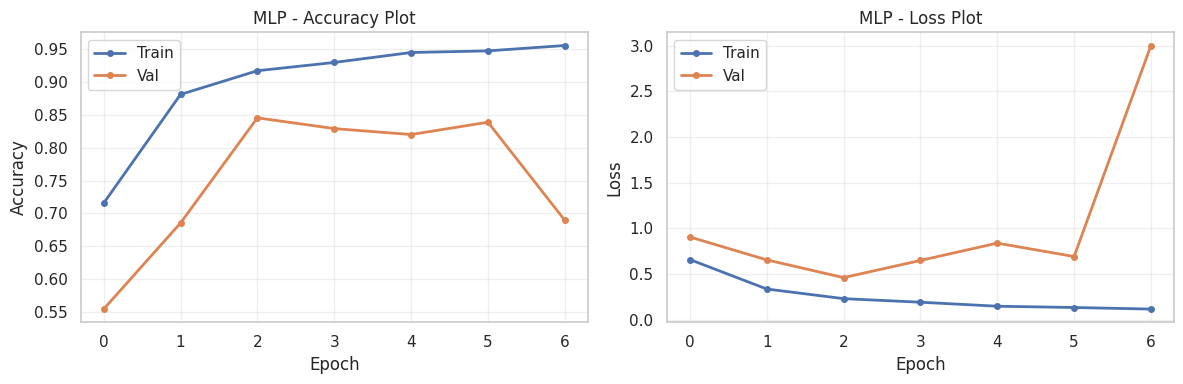

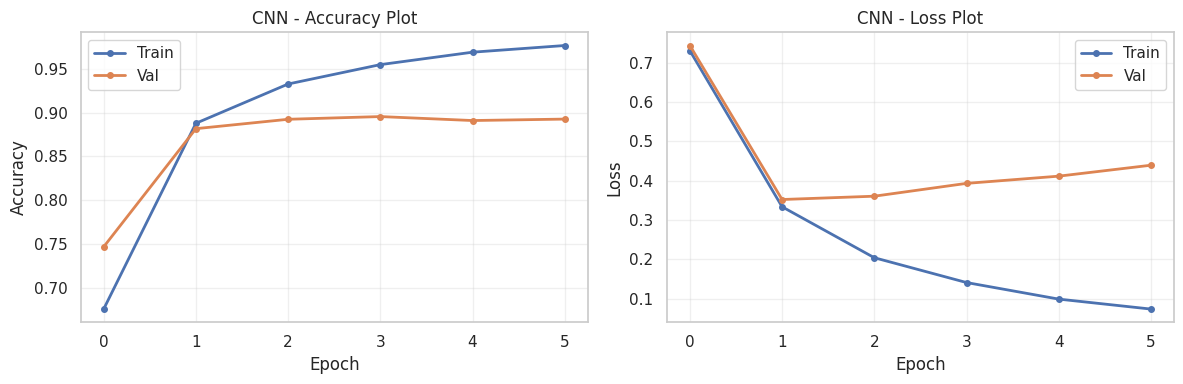

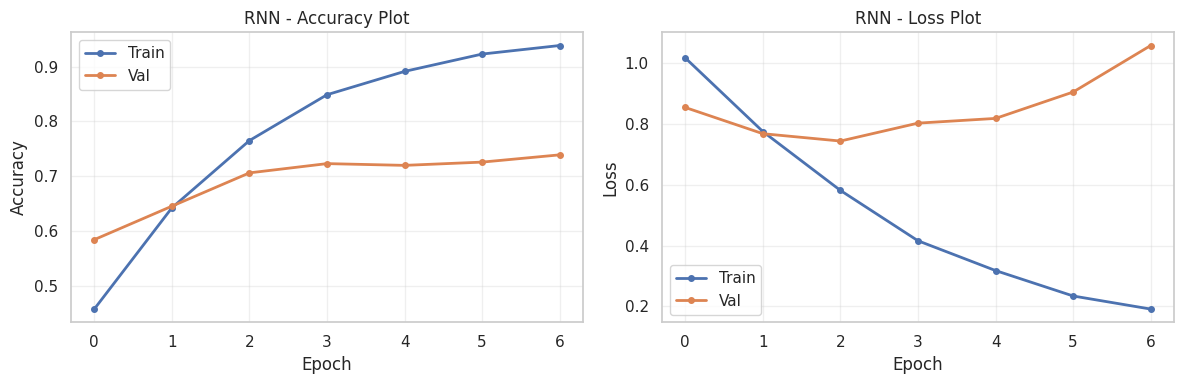

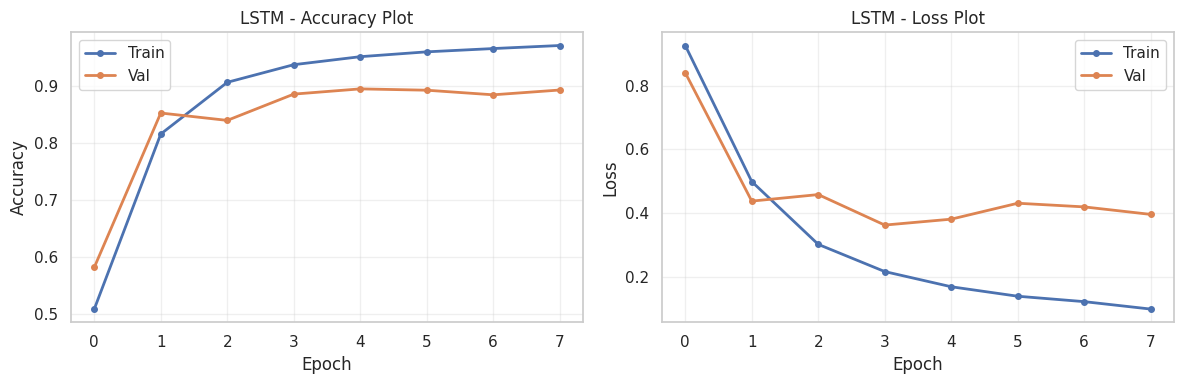

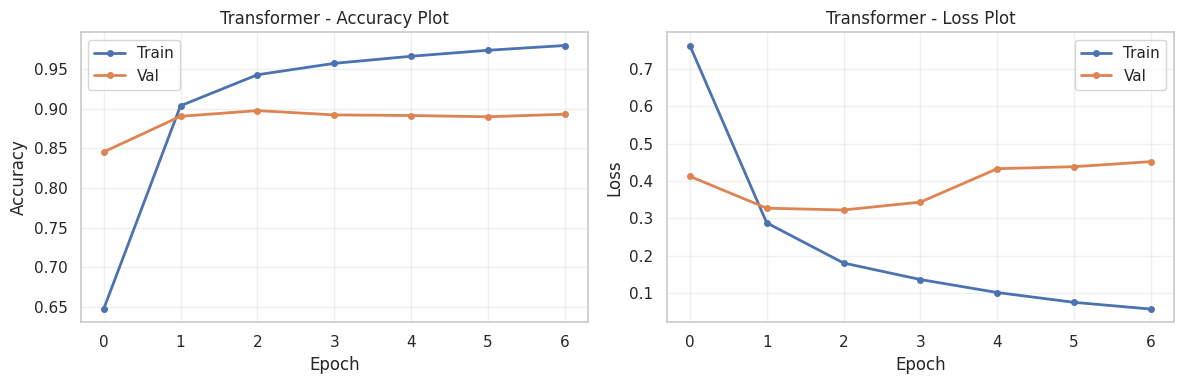

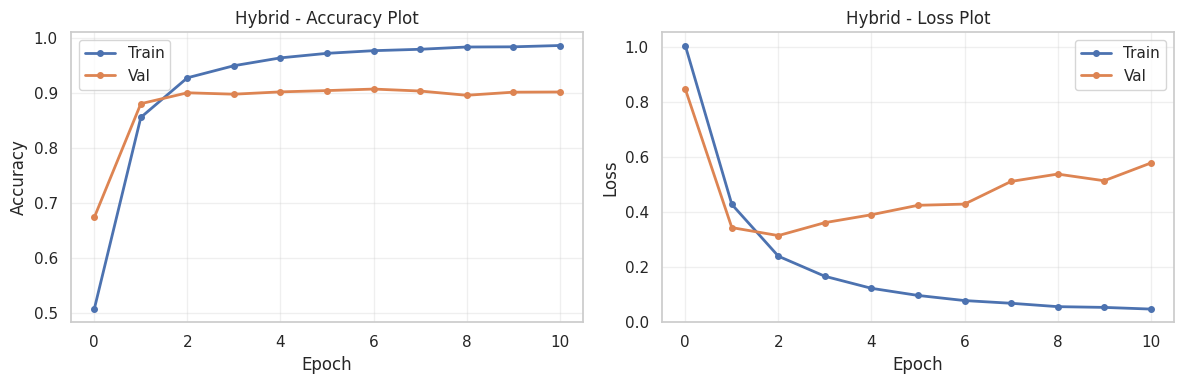

In [ ]:
def plot_acc_loss(history, model_name):
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], marker='o', markersize=4, label='Train', linewidth=2)
    plt.plot(history.history['val_accuracy'], marker='o', markersize=4, label='Val', linewidth=2)
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.title(f'{model_name} - Accuracy Plot')
    plt.grid(True, alpha=0.3)

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], marker='o', markersize=4, label='Train', linewidth=2)
    plt.plot(history.history['val_loss'], marker='o', markersize=4, label='Val', linewidth=2)
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.title(f'{model_name} - Loss Plot')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_acc_loss(history_mlp, "MLP")
plot_acc_loss(history_cnn, "CNN")
plot_acc_loss(history_rnn, "RNN")
plot_acc_loss(history_lstm, "LSTM")
plot_acc_loss(history_transformer, "Transformer")
plot_acc_loss(history_hybrid, "Hybrid")

# **10. Model Testing**

### **10.1 Predict Sentiment of New Tweet**

In [ ]:
!pip install vaderSentiment

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 10.6 MB/s eta 0:00:00


In [ ]:
import re

def clean_tweet(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"#", "", text)
    text = re.sub(r"\d+", "", text)
    text = re.sub(r"[^\w\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

In [ ]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

def predict_new_tweet():
    analyzer = SentimentIntensityAnalyzer()

    while True:
        text = input('Enter a Tweet: ').strip()

        if text.lower() in ['exit', 'quit', 'end', 'stop', 'close', 'finish']:
            print("Exiting Prediction.")
            break

        if not text:
            print("Please enter a non-empty tweet.")
            continue

        cleaned = clean_tweet(text)

        s = analyzer.polarity_scores(cleaned)

        if s['compound'] > 0.05:
            vader_res = 'Positive'
        elif s['compound'] < -0.05:
            vader_res = 'Negative'
        else:
            vader_res = 'Neutral'

        print(f"Cleaned Tweet: {cleaned}")
        print(f"Sentiment: {vader_res}")
        print(f"Breakdown: {s}\n")

predict_new_tweet()

Enter a Tweet: Praying for #peace 🙏🕊️ no more war please 💙💛 stay strong Ukraine 🇺🇦❤️ the world stands with you ✨
Cleaned Tweet: praying for peace no more war please stay strong ukraine the world stands with you
Sentiment: Positive
Breakdown: {'neg': 0.083, 'neu': 0.339, 'pos': 0.578, 'compound': 0.9204}

Enter a Tweet: Latest update 📰: Russia 🇷🇺 and Ukraine 🇺🇦 meeting again @today 🤝 more discussions expected tomorrow ⏳📅
Cleaned Tweet: latest update russia and ukraine meeting again more discussions expected tomorrow
Sentiment: Neutral
Breakdown: {'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0}

Enter a Tweet: This war is horrible, 😡💔 innocent lives lost 😢🔥 families destroyed 🏠💥 when will this END... 😞🕯️
Cleaned Tweet: this war is horrible innocent lives lost families destroyed when will this end
Sentiment: Negative
Breakdown: {'neg': 0.554, 'neu': 0.343, 'pos': 0.103, 'compound': -0.8885}

Enter a Tweet: close
Exiting Prediction.
